In [ ]:
# Imports

import pandas as pd
import os

In [ ]:
!pip install tqdm

In [ ]:
# Importing Datasets from Kaggle

# kaggle api token can be generated in your profile settings : https://www.kaggle.com/settings
# save kaggle api token in secrets

from google.colab import userdata
!export KAGGLE_API_TOKEN={userdata.get('KAGGLE_API_TOKEN')}

import kagglehub

# Download latest version of datasets
ds2 = kagglehub.dataset_download("jeftaadriel/oia-odir-dataset")

Using Colab cache for faster access to the 'oia-odir-dataset' dataset.


In [ ]:
# Convert files to csv format
off_site_file = pd.read_excel(f"{ds2}/Off-site Test Set/Annotation/off-site test annotation (English).xlsx")
off_site_file.to_csv("off_site_test_annotation.csv", index=None, header=True)

on_site_file = pd.read_excel(f"{ds2}/On-site Test Set/Annotation/on-site test annotation (English).xlsx")
on_site_file.to_csv("on_site_test_annotation.csv", index=None, header=True)

training_file = pd.read_excel(f"{ds2}/Training Set/Annotation/training annotation (English).xlsx")
training_file.to_csv("training_annotation.csv", index=None, header=True)

# Base paths for images
base_path_off_site = ds2 + '/Off-site Test Set/Images/'
base_path_on_site = ds2 + '/On-site Test Set/Images/'
base_path_training = ds2 + '/Training Set/Images/'

# Add image paths to a DataFrame
def process_fundus_image_paths(df, base_path, left_col='Left-Fundus', right_col='Right-Fundus'):
    def add_image_path(filename, current_base_path):
        if pd.isna(filename):
            return filename
        return os.path.join(current_base_path, filename)

    df[left_col] = df[left_col].apply(lambda x: add_image_path(x, base_path))
    df[right_col] = df[right_col].apply(lambda x: add_image_path(x, base_path))
    return df

# Apply to each DataFrame
off_site_file = process_fundus_image_paths(off_site_file, base_path_off_site)
on_site_file = process_fundus_image_paths(on_site_file, base_path_on_site)
training_file = process_fundus_image_paths(training_file, base_path_training)

# Combine all DataFrames into one
df_ds2 = pd.concat([off_site_file, on_site_file, training_file], ignore_index=True)

# Remove specified columns
columns_to_remove = ['ID', 'Patient Age', 'Patient Sex', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
df_ds2 = df_ds2.drop(columns=columns_to_remove)

# Convert Keywords into diagnosis for each eye
disease_mapping = {
    'normal': 'NORMAL',
    'diabetic retinopathy': 'DIABETIC_RETINOPATHY',
    'glaucoma': 'GLAUCOMA',
    'cataract': 'CATARACT',
    'macular degeneration': 'AGE_RELATED_MACULAR_DEGENERATION',
    'age-related macular degeneration': 'AGE_RELATED_MACULAR_DEGENERATION',
    'hypertensive retinopathy': 'HYPERTENSION',
    'myopia': 'MYOPIA',
}

df_left = df_ds2[['Left-Fundus', 'Left-Diagnostic Keywords']].copy()
df_right = df_ds2[['Right-Fundus', 'Right-Diagnostic Keywords']].copy()

df_left.columns = ['image_path', 'eye_disease']
df_right.columns = ['image_path', 'eye_disease']

# Get unique disease codes for column names
disease_codes = list(set(disease_mapping.values()))
disease_codes.append('OTHER_DISEASES')

def parse_diagnosis(df):
    # Initialize all disease columns with 0
    for disease in disease_codes:
        df[disease] = 0

    # Parse each row's diagnostic keywords
    for idx, keywords in df['eye_disease'].items():
        if pd.isna(keywords):
            continue

        # Convert to lowercase for matching
        keywords_lower = str(keywords).lower()

        disease_found = False

        # Check for each disease keyword in the mapping
        for keyword, disease_code in disease_mapping.items():
            if keyword in keywords_lower:
                df.at[idx, disease_code] = 1
                disease_found = True

        if not disease_found:
            df.at[idx, 'OTHER_DISEASES'] = 1

    df = df.drop('eye_disease', axis=1)

    return df

# Apply to both dataframes
df_left = parse_diagnosis(df_left)
df_right = parse_diagnosis(df_right)

# Combine to final dataset
df_ds2 = pd.concat([df_left, df_right], ignore_index=True)

print(df_left)
print(df_right)


                                             image_path  DIABETIC_RETINOPATHY  \
0     /kaggle/input/oia-odir-dataset/Off-site Test S...                     0   
1     /kaggle/input/oia-odir-dataset/Off-site Test S...                     0   
2     /kaggle/input/oia-odir-dataset/Off-site Test S...                     0   
3     /kaggle/input/oia-odir-dataset/Off-site Test S...                     0   
4     /kaggle/input/oia-odir-dataset/Off-site Test S...                     0   
...                                                 ...                   ...   
4995  /kaggle/input/oia-odir-dataset/Training Set/Im...                     0   
4996  /kaggle/input/oia-odir-dataset/Training Set/Im...                     0   
4997  /kaggle/input/oia-odir-dataset/Training Set/Im...                     0   
4998  /kaggle/input/oia-odir-dataset/Training Set/Im...                     0   
4999  /kaggle/input/oia-odir-dataset/Training Set/Im...                     0   

      AGE_RELATED_MACULAR_D

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler

In [ ]:
class EyeDiseaseDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = self.dataframe.iloc[:, 1:].values.astype(float) # Get disease labels as numpy array

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0] # First column is image_path
        image = Image.open(img_path).convert('RGB')
        labels = torch.tensor(self.labels[idx], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, labels

In [ ]:
def crop_black_borders(image):
    # Convert PIL Image to NumPy array
    img_np = np.array(image)

    # Threshold for black pixels
    # Pixels with R, G, B values all below this threshold will be considered black
    BLACK_THRESHOLD = 10

    non_black_pixels = np.any(img_np > BLACK_THRESHOLD, axis=2)

    # Find rows and columns that contain non-black pixels
    rows = np.any(non_black_pixels, axis=1)
    cols = np.any(non_black_pixels, axis=0)

    # Get the min/max indices for cropping
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]

    # Crop the NumPy array
    cropped_img_np = img_np[rmin:rmax+1, cmin:cmax+1]

    # Convert back to PIL Image
    return Image.fromarray(cropped_img_np)

In [ ]:
data_transforms = transforms.Compose([
    transforms.Lambda(crop_black_borders), # Apply custom cropping function
    transforms.Resize((224, 224)), # Resize images to 224x224 pixels
    transforms.ToTensor(), # Convert PIL image to PyTorch tensor
])

full_dataset = EyeDiseaseDataset(dataframe=df_ds2, transform=data_transforms)

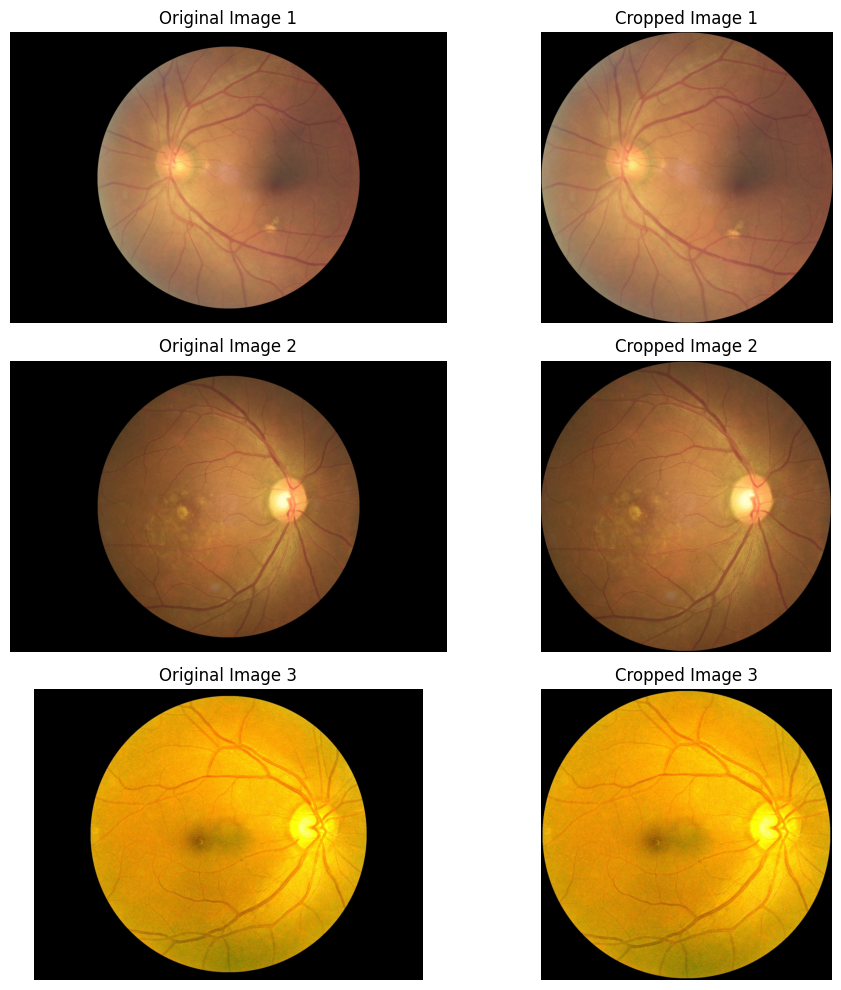

In [ ]:
# Select a few sample image paths
sample_image_paths = df_ds2['image_path'].sample(3, random_state=68).tolist()

plt.figure(figsize=(10, 10))

for i, img_path in enumerate(sample_image_paths):
    original_image = Image.open(img_path).convert('RGB')
    cropped_image = crop_black_borders(original_image)

    # Display original image
    plt.subplot(3, 2, 2 * i + 1)
    plt.imshow(original_image)
    plt.title(f"Original Image {i+1}")
    plt.axis('off')

    # Display cropped image
    plt.subplot(3, 2, 2 * i + 2)
    plt.imshow(cropped_image)
    plt.title(f"Cropped Image {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Split the dataset
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [0.8, 0.2])

# Data loaders
BATCH_SIZE = 32
NUM_WORKERS = 4

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,  # Keep workers alive between epochs
    prefetch_factor=2  # Prefetch 2 batches per worker
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Train batches: 250, Test batches: 63
Using device: cuda


In [ ]:
# Load a pre-trained model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all parameters efficiently
for param in model.parameters():
    param.requires_grad = False

# Modify final layer
num_features = model.fc.in_features
num_classes = len(disease_codes)
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),  # Add dropout for regularization
    nn.Linear(num_features, num_classes)
)

model = model.to(device)

# Use DataParallel for multi-GPU
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 229MB/s]


Total parameters: 11,180,616
Trainable parameters: 4,104


In [ ]:
# Loss function
criterion = nn.BCEWithLogitsLoss()

# Optimizer with weight decay and learning rate scheduling
optimizer = optim.Adam(model.fc.parameters(), lr=0.001, weight_decay=1e-4)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

# Mixed precision training scaler (for faster training on GPUs)
scaler = GradScaler() if torch.cuda.is_available() else None

print(f"Optimizer: Adam with lr=0.001, weight_decay=1e-4")
if scaler:
    print("Mixed precision training: ENABLED")

Optimizer: Adam with lr=0.001, weight_decay=1e-4
Mixed precision training: ENABLED


/tmp/ipykernel_1388/560873906.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if torch.cuda.is_available() else None


In [ ]:
def train_model(model, criterion, optimizer, scheduler, train_loader, val_loader, device, num_epochs=10, scaler=None):
    start_time = time.time()

    # For tracking best model
    best_val_loss = float('inf')
    best_model_state = None

    # For tracking metrics
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch + 1}/{num_epochs}')
        print('-' * 40)

        # Training phase
        model.train()
        running_train_loss = 0.0

        # Progress bar (optional - requires tqdm: pip install tqdm)
        from tqdm import tqdm
        train_pbar = tqdm(train_loader, desc=f'Train Epoch {epoch+1}', leave=False)

        for batch_idx, (inputs, targets) in enumerate(train_pbar):
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)  # More efficient than zero_grad()

            # Mixed precision training
            if scaler:
                with autocast():
                    predictions = model(inputs)
                    loss = criterion(predictions, targets)

                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                predictions = model(inputs)
                loss = criterion(predictions, targets)
                loss.backward()
                optimizer.step()

            running_train_loss += loss.item() * inputs.size(0)

            # Update progress bar
            train_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # Validation phase
        model.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            val_pbar = tqdm(val_loader, desc=f'Val Epoch {epoch+1}', leave=False)
            for inputs, targets in val_pbar:
                inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)

                if scaler:
                    with autocast():
                        predictions = model(inputs)
                        loss = criterion(predictions, targets)
                else:
                    predictions = model(inputs)
                    loss = criterion(predictions, targets)

                running_val_loss += loss.item() * inputs.size(0)
                val_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        # Update learning rate
        scheduler.step(epoch_val_loss)

        print(f'Train Loss: {epoch_train_loss:.4f} | Validation Loss: {epoch_val_loss:.4f}')
        print(f'Learning Rate: {optimizer.param_groups[0]["lr"]:.6f}')

        # Save best model
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}  # Move to CPU to save GPU memory
            print(f'  -> New best model! (Validation Loss: {best_val_loss:.4f})')

    elapsed_time = time.time() - start_time
    print(f'\nTraining complete in {elapsed_time // 60:.0f}m {elapsed_time % 60:.0f}s')
    print(f'Best Validation Loss: {best_val_loss:.4f}')

    # Load the best model state
    model.load_state_dict(best_model_state)
    return model, train_losses, val_losses, best_model_state

In [ ]:
print("Starting training...")
model, train_losses, val_losses, best_model_state = train_model(
    model, criterion, optimizer, scheduler,
    train_loader, test_loader, device,
    num_epochs=5, scaler=scaler
)

# Save the best model weights
torch.save(best_model_state, 'best_model_weights.pth')
print("Best model weights saved to 'best_model_weights.pth'")

Starting training...

Epoch 1/5
----------------------------------------


Train Epoch 1:   0%|          | 0/250 [00:00<?, ?it/s]/tmp/ipykernel_1388/2881772059.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Val Epoch 1:   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_1388/2881772059.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Train Loss: 0.2791 | Validation Loss: 0.2397
Learning Rate: 0.001000
  -> New best model! (Validation Loss: 0.2397)

Epoch 2/5
----------------------------------------


Train Loss: 0.2494 | Validation Loss: 0.2379
Learning Rate: 0.001000
  -> New best model! (Validation Loss: 0.2379)

Epoch 3/5
----------------------------------------


Train Loss: 0.2440 | Validation Loss: 0.2291
Learning Rate: 0.001000
  -> New best model! (Validation Loss: 0.2291)

Epoch 4/5
----------------------------------------


Train Loss: 0.2412 | Validation Loss: 0.2307
Learning Rate: 0.001000

Epoch 5/5
----------------------------------------


Train Loss: 0.2394 | Validation Loss: 0.2263
Learning Rate: 0.001000
  -> New best model! (Validation Loss: 0.2263)

Training complete in 39m 36s
Best Validation Loss: 0.2263
Best model weights saved to 'best_model_weights.pth'


In [ ]:
def evaluate_model(model, test_loader, device, scaler=None):
    model.eval()
    test_loss = 0.0
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in tqdm.tqdm(test_loader, desc='Evaluating'):
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)

            if scaler:
                with autocast():
                    predictions = model(inputs)
                    loss = criterion(predictions, targets)
            else:
                predictions = model(inputs)
                loss = criterion(predictions, targets)

            test_loss += loss.item() * inputs.size(0)

            # Apply sigmoid to get probabilities (more efficient on GPU)
            probabilities = torch.sigmoid(predictions)
            all_predictions.extend(probabilities.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    test_loss = test_loss / len(test_loader.dataset)
    print(f"\nFinal Test Loss: {test_loss:.4f}")

    # Calculate additional metrics
    all_predictions = np.array(all_predictions)
    all_targets = np.array(all_targets)

    # Binary predictions at 0.5 threshold
    binary_preds = (all_predictions > 0.5).astype(np.float32)

    # Calculate accuracy per class
    class_accuracies = (binary_preds == all_targets).mean(axis=0)
    print(f"Mean class accuracy: {class_accuracies.mean():.4f}")

    return test_loss, all_predictions, all_targets

In [ ]:
# Evaluate on test set
test_loss, predictions, targets = evaluate_model(model, test_loader, device, scaler)
print("\nModel training and evaluation complete!")

np.save('predictions.npy', predictions)
np.save('targets.npy', targets)
print("Predictions and targets saved to disk")

Evaluating:   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_1388/4293492016.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Evaluating: 100%|██████████| 63/63 [01:36<00:00,  1.53s/it]


Final Test Loss: 0.2263
Mean class accuracy: 0.8964

Model training and evaluation complete!
Predictions and targets saved to disk


In [ ]:
checkpoint = {
    'epoch': 5,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'num_classes': num_classes,
    'model_architecture': 'resnet18',
    'disease_codes': disease_codes,  # Save the class names
    'batch_size': BATCH_SIZE,
    'learning_rate': 0.001,
}

SAVE_DIR = 'saved_models'

torch.save(checkpoint, f'{SAVE_DIR}/checkpoint.pth')
print(f"Checkpoint saved to: {SAVE_DIR}/checkpoint.pth")


Checkpoint saved to: saved_models/checkpoint.pth
